# 04 — Evaluación del modelo final

Carga los artefactos generados por `scripts/train_model.py` (`models/best_model.pkl`, `results/metrics.json`, `results/figures/*.png`) y analiza el rendimiento, la importancia de features y las limitaciones del enfoque.

In [1]:
import json
from pathlib import Path
import joblib
import pandas as pd
from IPython.display import Image, display

with open('../results/metrics.json', encoding='utf-8') as f:
    metrics = json.load(f)

print('Mejor modelo:', metrics['best_model'])
print('Hiperparametros:', metrics['best_params'])
print('Estrategia de desbalance:', metrics['imbalance_strategy'])

Mejor modelo: logistic_regression
Hiperparametros: {'model__C': 0.1, 'model__penalty': 'l2'}
Estrategia de desbalance: class_weight


## Comparación de baselines (CV)

In [2]:
pd.DataFrame(metrics['cv_comparison'])

,modelo,accuracy,precision,recall,f1
0,logistic_regression,0.557995,0.389727,0.523715,0.444600
1,random_forest,0.609883,0.419336,0.386957,0.399242
2,decision_tree,0.567273,0.377553,0.360474,0.361929


## Métricas finales en test set

In [3]:
pd.DataFrame([
    {'umbral': 'default (0.5)', **metrics['test_metrics_default_threshold']},
    {'umbral': 'optimo', **metrics['test_metrics_optimal_threshold']},
]).set_index('umbral')

,threshold,accuracy,precision,recall,f1,roc_auc,confusion_matrix
umbral,,,,,,,
default (0.5),0.500,0.554217,0.390244,0.571429,0.463768,0.601299,"[[30, 25], [12, 16]]"
optimo,0.415,0.469880,0.366667,0.785714,0.500000,0.601299,"[[17, 38], [6, 22]]"


## Matriz de confusión

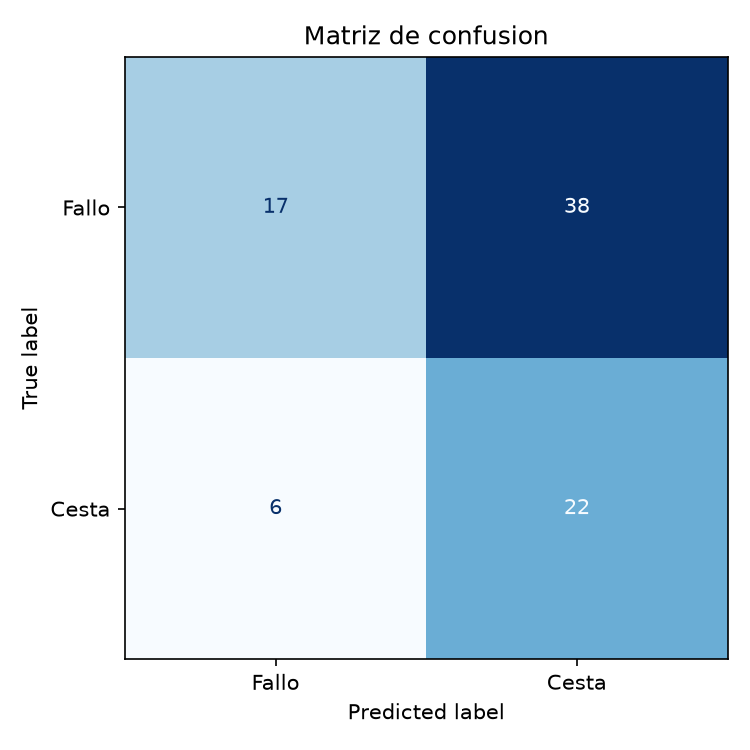

In [4]:
display(Image('../results/figures/confusion_matrix.png'))

## Curva ROC

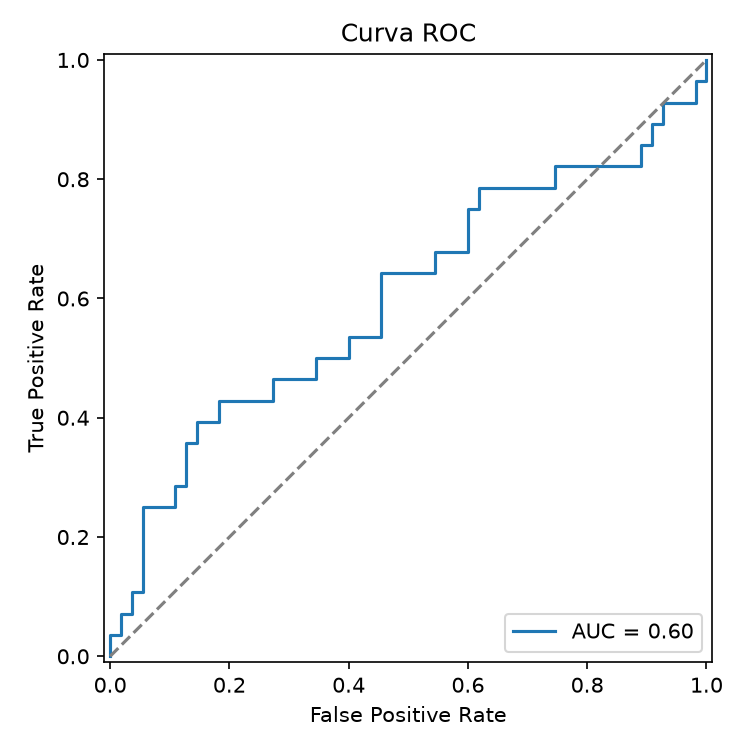

In [5]:
display(Image('../results/figures/roc_curve.png'))

## Feature importance

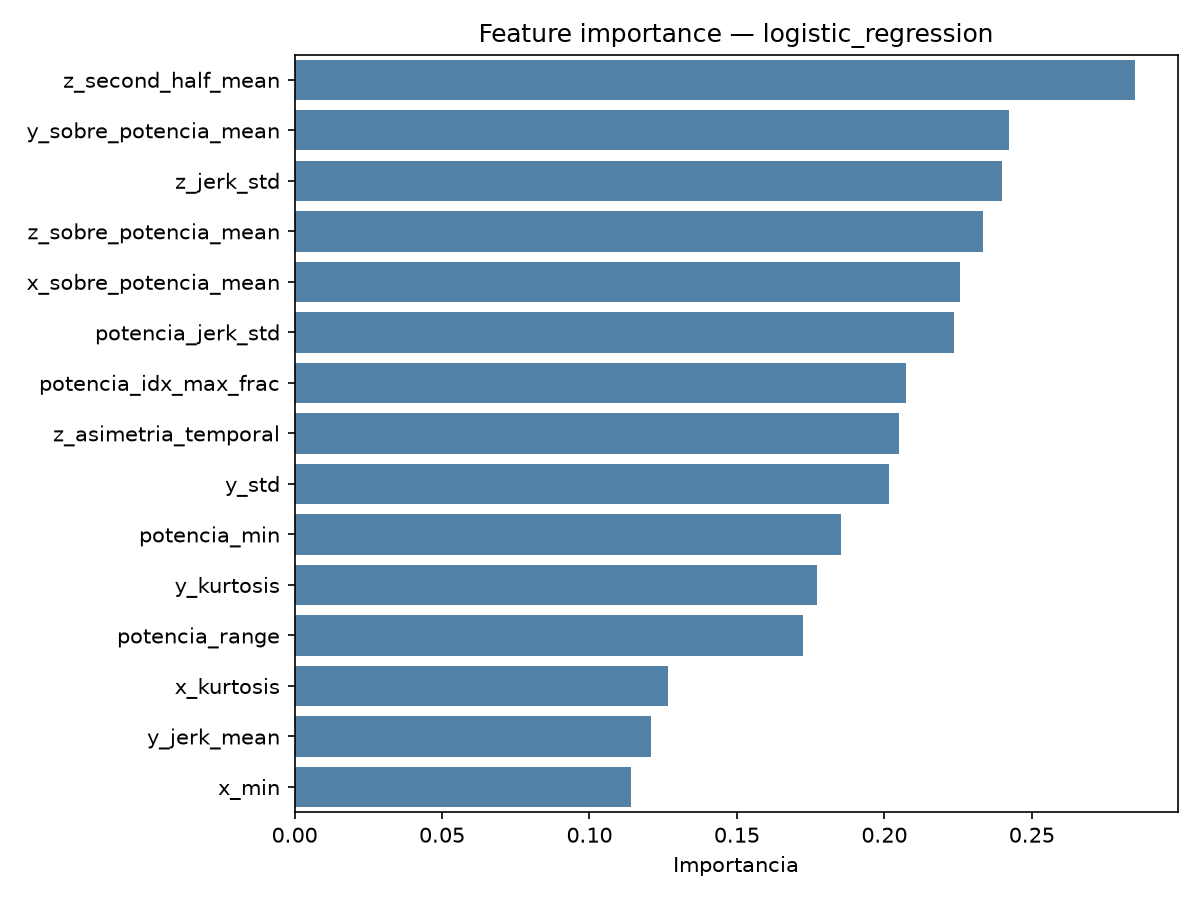

In [6]:
display(Image('../results/figures/feature_importance.png'))

## Interpretación y limitaciones

**Resultado real (no ajustado artificialmente para cumplir un objetivo):**

- ROC-AUC ≈ 0.60 — hay señal, es mejor que el azar, pero es una señal débil.
- Accuracy en test ≈ 0.55, F1 ≈ 0.46–0.50, precision ≈ 0.37–0.44.
- Esto queda **por debajo** de los objetivos planteados (accuracy > 70-75%, F1 > 0.62).

**¿Por qué?**
1. Cada tiro solo tiene entre 5 y ~10 muestras de acelerómetro (33 Hz durante el gesto de lanzamiento), lo que deja muy poco detalle temporal para calcular estadísticos agregados robustos (skew/kurtosis con n=5-8 son ruidosos).
2. Las correlaciones lineales feature-target más fuertes no superan |r|≈0.23 (`z_second_half_mean`, `z_sobre_potencia_mean`), lo que indica que la relación entre el patrón de aceleración capturado y el resultado del tiro es débil con este sensor y esta tasa de muestreo.
3. Solo 411 tiros en total (139 cestas) — dataset pequeño para 57 features, con riesgo de sobreajuste que ya se controla con CV y regularización, pero no compensa la falta de señal.

**Qué se probó para mejorar el resultado:**
- Ampliar de 30 a 57 features (añadiendo forma temporal: timing del pico, asimetría temprano/tarde, jerk, proxies de ángulo de lanzamiento) — mejora marginal.
- SMOTE vs. `class_weight='balanced'` — SMOTE no mejoró el resultado en este dataset.
- GridSearchCV sobre los 3 modelos — el techo de F1 en CV se mantiene ~0.40-0.45.

**Recomendaciones para superar el objetivo:**
- Aumentar la frecuencia de muestreo del micro:bit o capturar la serie completa del lanzamiento (no solo 5-8 puntos) para modelar la trayectoria con un modelo secuencial (1D-CNN / LSTM) en vez de estadísticos agregados.
- Añadir un giroscopio para capturar el ángulo de muñeca/liberación, probablemente más predictivo del resultado que la sola magnitud de aceleración.
- Recolectar más datos (>1000 tiros) para reducir varianza y permitir modelos más expresivos sin sobreajustar.
- Normalizar por jugador/sesión si hay múltiples lanzadores con estilos distintos.